# Tarang v9.3 — Cleaned S Annotations Retrain

## The decisive experiment

v9.2 proved that 41% of test S beats and 24% of train S beats are **not premature** (prematurity_index > 0.95). A supraventricular ectopic beat is by definition premature — these beats cannot be S. The model has been trained to classify non-premature beats as "S" and correctly learned that this is impossible.

**This notebook cleans the S annotations and retrains from scratch.**

### What "cleaning" means

For every beat currently labeled 'S':
- If `prematurity_index < 0.95` → keep as 'S' (genuinely or mildly premature)
- If `prematurity_index >= 0.95` → relabel to 'N' (not ectopic by definition)

This is applied to train, val, AND test. The cleaned test set is the fair evaluation — we're no longer penalizing the model for correctly refusing to call non-premature beats "S."

### What we're testing

| Outcome | Interpretation |
|---|---|
| S F1 jumps significantly on cleaned test | Label noise was the blocker. 9 versions of architecture changes were chasing noise. |
| S F1 stays low on cleaned test | The problem is genuine model failure. Even real premature S beats are too hard. |

### Cost

- 1 gate retrain (~5 min)
- 1 SV retrain (~5 min)
- Total: ~15 min GPU + 5 min CPU for data prep

This is the single highest-value experiment in the project.


## Setup — load v9 data, models, and define the cleaning function

In [1]:
import os, json, glob, warnings
from collections import Counter
from datetime import datetime

import wfdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import regularizers
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset'
def find_dir(base, *candidates):
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p): return p
    for c in candidates:
        for v in [c, c.lower(), c.upper(), c.title()]:
            p = os.path.join(base, v)
            if os.path.isdir(p): return p
    return os.path.join(base, candidates[0])

MITBIH_PATH = find_dir(BASE, 'mit-bih-arrhythmia-database-1.0.0', 'mitbih')
SVDB_PATH   = find_dir(BASE, 'mit-bih-supraventricular-arrhythmia-database-1.0.0', 'svdb')
OUTPUTS_V9  = 'outputs_v9'
OUTPUTS_V93 = 'outputs_v93'
os.makedirs(OUTPUTS_V93, exist_ok=True)

SOURCE_FS, TARGET_FS = 360, 250
WINDOW_LEN, WINDOW_PRE, WINDOW_POST = 130, 65, 65
V_RECALL_FLOOR = 0.85
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

# The cleaning threshold — beats with prematurity_index >= this are relabeled S→N
PREMATURITY_THRESHOLD = 0.95

BEAT_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V','F':'V',
    '/':'Q','f':'Q','Q':'Q',
}
CLASSES_TO_USE = ['N','S','V']
MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS = [105, 124, 214, 220]
SVDB_RECORDS = [str(i) for i in range(800, 895)]

# ── Load v9 data checkpoint ──────────────────────────────────────────────────
cp = np.load(f'{OUTPUTS_V9}/data_checkpoint.npz', allow_pickle=True)
mb_beats, mb_rr = cp['mb_beats'], cp['mb_rr']
mb_labels, mb_recs = cp['mb_labels'], cp['mb_recs']
sv_beats, sv_rr = cp['sv_beats'], cp['sv_rr']
sv_labels, sv_recs = cp['sv_labels'], cp['sv_recs']

X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])
le = LabelEncoder(); le.fit(CLASSES_TO_USE)
y_all = le.transform(y_raw_all)
n_idx = int(np.where(le.classes_=='N')[0][0])
s_idx = int(np.where(le.classes_=='S')[0][0])
v_idx = int(np.where(le.classes_=='V')[0][0])

test_recs_set = {f'mitbih_{r}' for r in MITBIH_TEST_RECORDS}
val_recs_set  = {f'mitbih_{r}' for r in MITBIH_VAL_RECORDS}
test_mask  = np.isin(recs_all, list(test_recs_set))
val_mask   = np.isin(recs_all, list(val_recs_set))
train_mask = ~(test_mask | val_mask)

# RR normalization (computed on original train, same as v9)
RR_MEAN = X_rr_all[train_mask].mean(axis=0)
RR_STD  = X_rr_all[train_mask].std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8
X_rr_all_norm = (X_rr_all - RR_MEAN) / RR_STD

print(f"Loaded v9 data. Original counts:")
print(f"  Train: {int(train_mask.sum())}  S: {int(np.sum(y_raw_all[train_mask]=='S'))}")
print(f"  Val  : {int(val_mask.sum())}   S: {int(np.sum(y_raw_all[val_mask]=='S'))}")
print(f"  Test : {int(test_mask.sum())}  S: {int(np.sum(y_raw_all[test_mask]=='S'))}")
print(f"\nCleaning threshold: prematurity_index >= {PREMATURITY_THRESHOLD} → S relabeled to N")


Loaded v9 data. Original counts:
  Train: 56621  S: 13889
  Val  : 8492   S: 125
  Test : 58467  S: 961

Cleaning threshold: prematurity_index >= 0.95 → S relabeled to N


## Step 1 — Clean the S annotations

For every beat labeled 'S', check its prematurity_index (column 6 of X_rr_all). If >= 0.95, relabel to 'N'.

This is applied to train, val, and test identically — the cleaning is a property of the data, not a training-time choice.

In [2]:
# ── Clean S annotations ──────────────────────────────────────────────────────
premat_all = X_rr_all[:, 6]  # prematurity_index for every beat

# Original S mask
s_original_mask = y_raw_all == 'S'

# Beats to relabel: S AND prematurity_index >= threshold
relabel_mask = s_original_mask & (premat_all >= PREMATURITY_THRESHOLD)

# Build cleaned labels
y_raw_clean = y_raw_all.copy()
y_raw_clean[relabel_mask] = 'N'
y_clean = le.transform(y_raw_clean)

# Report
print(f"{'='*70}")
print(f"S ANNOTATION CLEANING")
print(f"{'='*70}")
print(f"\nThreshold: prematurity_index >= {PREMATURITY_THRESHOLD} → S relabeled to N")
print(f"\n{'Split':<8} {'Original S':>12} {'Cleaned S':>12} {'Relabeled':>12} {'% removed':>12}")
print(f"{'-'*60}")
for split_name, mask in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    orig_s = int(np.sum((y_raw_all == 'S') & mask))
    clean_s = int(np.sum((y_raw_clean == 'S') & mask))
    relabeled = orig_s - clean_s
    pct = relabeled / max(orig_s, 1) * 100
    print(f"{split_name:<8} {orig_s:>12} {clean_s:>12} {relabeled:>12} {pct:>11.1f}%")

# Also report what the relabeled beats actually are (raw symbol-wise, for test)
print(f"\n{'='*70}")
print(f"WHAT GOT RELABELED (test set, by raw annotation source)")
print(f"{'='*70}")
# We don't have raw symbols here, but we can show prematurity distribution
test_relabel = relabel_mask & test_mask
test_relabel_premat = premat_all[test_relabel]
print(f"  {int(test_relabel.sum())} beats relabeled S→N in test")
print(f"  Their prematurity_index distribution:")
print(f"    min: {test_relabel_premat.min():.3f}")
print(f"    median: {np.median(test_relabel_premat):.3f}")
print(f"    max: {test_relabel_premat.max():.3f}")
print(f"  These are beats that came on-time or late — not ectopic by definition.")

# Per-patient test breakdown
print(f"\n{'='*70}")
print(f"PER-PATIENT TEST S COUNTS (original vs cleaned)")
print(f"{'='*70}")
print(f"{'Patient':<14} {'Orig S':>8} {'Clean S':>8} {'Removed':>8} {'% removed':>10}")
print(f"{'-'*50}")
for rec_tag in sorted(set(recs_all[test_mask])):
    pat_mask = (recs_all == rec_tag) & test_mask
    orig = int(np.sum((y_raw_all == 'S') & pat_mask))
    clean = int(np.sum((y_raw_clean == 'S') & pat_mask))
    if orig == 0: continue
    removed = orig - clean
    pct = removed / orig * 100 if orig > 0 else 0
    print(f"{rec_tag:<14} {orig:>8} {clean:>8} {removed:>8} {pct:>9.1f}%")


S ANNOTATION CLEANING

Threshold: prematurity_index >= 0.95 → S relabeled to N

Split      Original S    Cleaned S    Relabeled    % removed
------------------------------------------------------------
Train           13889        10604         3285        23.7%
Val               125           86           39        31.2%
Test              961          566          395        41.1%

WHAT GOT RELABELED (test set, by raw annotation source)
  395 beats relabeled S→N in test
  Their prematurity_index distribution:
    min: 0.951
    median: 1.005
    max: 1.430
  These are beats that came on-time or late — not ectopic by definition.

PER-PATIENT TEST S COUNTS (original vs cleaned)
Patient          Orig S  Clean S  Removed  % removed
--------------------------------------------------
mitbih_101            3        3        0       0.0%
mitbih_108            4        4        0       0.0%
mitbih_112            2        2        0       0.0%
mitbih_114           12        8        4      33.3

## Step 2 — Build cleaned train/val/test arrays

Same architecture and training procedure as v9. The only difference is the cleaned labels.

In [3]:
# ── Build cleaned splits ─────────────────────────────────────────────────────
X_train = X_all[train_mask]
X_rr_train = X_rr_all[train_mask]
X_rr_train_norm = X_rr_all_norm[train_mask]
y_train = y_clean[train_mask]
y_train_raw = y_raw_clean[train_mask]
recs_train = recs_all[train_mask]

X_val = X_all[val_mask]
X_rr_val = X_rr_all[val_mask]
X_rr_val_norm = X_rr_all_norm[val_mask]
y_val = y_clean[val_mask]
y_val_raw = y_raw_clean[val_mask]
recs_val = recs_all[val_mask]

X_test = X_all[test_mask]
X_rr_test = X_rr_all[test_mask]
X_rr_test_norm = X_rr_all_norm[test_mask]
y_test = y_clean[test_mask]
y_test_raw = y_raw_clean[test_mask]
recs_test = recs_all[test_mask]

print(f"Cleaned splits:")
print(f"  Train: {X_train.shape}  classes={Counter(y_train_raw)}")
print(f"  Val  : {X_val.shape}    classes={Counter(y_val_raw)}")
print(f"  Test : {X_test.shape}   classes={Counter(y_test_raw)}  (HELD OUT)")


Cleaned splits:
  Train: (56621, 130, 2)  classes=Counter({'N': 34410, 'V': 11607, 'S': 10604})
  Val  : (8492, 130, 2)    classes=Counter({'N': 8056, 'V': 350, 'S': 86})
  Test : (58467, 130, 2)   classes=Counter({'N': 51861, 'V': 6040, 'S': 566})  (HELD OUT)


## Step 3 — Augmentation (same as v9, on cleaned labels)

In [4]:
def augment_batch(X_c, X_rr_c, class_name, n_copies, rng=None):
    if rng is None: rng = np.random.default_rng(SEED)
    n = len(X_c)
    if n == 0 or n_copies == 0:
        return (np.empty((0,)+X_c.shape[1:], dtype=np.float32),
                np.empty((0,)+X_rr_c.shape[1:], dtype=np.float32))
    out_X = np.repeat(X_c, n_copies, axis=0)
    out_rr = np.repeat(X_rr_c, n_copies, axis=0)
    shift = rng.integers(-3, 4, size=len(out_X))
    out_X_aug = np.empty_like(out_X)
    for i, s in enumerate(shift):
        if s > 0:
            out_X_aug[i, :-s] = out_X[i, s:]; out_X_aug[i, -s:] = out_X[i, -1:]
        elif s < 0:
            out_X_aug[i, -s:] = out_X[i, :s]; out_X_aug[i, :-s] = out_X[i, :1]
        else:
            out_X_aug[i] = out_X[i]
    amp = rng.uniform(0.85, 1.15, size=(len(out_X), 1, 1)).astype(np.float32)
    out_X_aug *= amp
    out_X_aug += rng.normal(0, 0.02, size=out_X_aug.shape).astype(np.float32)
    if class_name == 'S':
        out_rr[:, 0] *= rng.uniform(0.55, 0.85, size=len(out_rr))
        out_rr[:, 1] *= rng.uniform(1.10, 1.40, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.20, 2.00, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    elif class_name == 'V':
        out_rr[:, 1] *= rng.uniform(1.20, 1.60, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.10, 1.80, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    return out_X_aug, out_rr

# Augment for gate training (same as v9)
print("Augmenting minority classes for Gate training...")
ecg_list = [X_train]; rr_list = [X_rr_train_norm]; y_list = [y_train]
n_per_class = Counter(y_train)
n_target = max(n_per_class.values()) // 2
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per_class.get(class_idx, 0)
    n_need = max(0, n_target - n_have)
    if n_need == 0:
        print(f"  {class_name}: have {n_have}, no augmentation needed")
        continue
    mask = y_train == class_idx
    X_c, rr_c = X_train[mask], X_rr_train_norm[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=y_train.dtype)
    ecg_list.append(X_aug); rr_list.append(rr_aug); y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, added {len(X_aug)} augmented")
X_train_aug = np.concatenate(ecg_list)
X_rr_train_aug = np.concatenate(rr_list)
y_train_aug = np.concatenate(y_list)
perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]; X_rr_train_aug = X_rr_train_aug[perm]; y_train_aug = y_train_aug[perm]

y_train_gate = (y_train_aug != n_idx).astype(np.float32)
y_val_gate   = (y_val != n_idx).astype(np.float32)
y_test_gate  = (y_test != n_idx).astype(np.float32)
print(f"\nGate training set: {X_train_aug.shape}  classes={Counter(y_train_aug)}")


Augmenting minority classes for Gate training...
  N: have 34410, no augmentation needed
  S: have 10604, added 10604 augmented
  V: have 11607, added 11607 augmented

Gate training set: (78832, 130, 2)  classes=Counter({0: 34410, 2: 23214, 1: 21208})


## Step 4 — Train gate on cleaned labels

In [5]:
def build_gate_model(ecg_shape=(WINDOW_LEN,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN,2,1), name='expand_chan')(ecg_in)
    for f,k,d in [(16,7,0.1),(32,5,0.1),(64,5,0.15),(64,3,0.0)]:
        x = tf.keras.layers.Conv2D(f,(k,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if k >= 5: x = tf.keras.layers.MaxPooling2D((2,1))(x); x = tf.keras.layers.SpatialDropout2D(d)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(r)
    m = tf.keras.layers.Concatenate()([x, r])
    m = tf.keras.layers.Dense(32, use_bias=False)(m)
    m = tf.keras.layers.BatchNormalization()(m)
    m = tf.keras.layers.Activation('relu')(m)
    m = tf.keras.layers.Dropout(0.35)(m)
    return tf.keras.Model(inputs=[ecg_in,rr_in],
                           outputs=tf.keras.layers.Dense(1,activation='sigmoid',name='gate_logit')(m),
                           name='Gate_v93')

print("Training gate on cleaned labels...")
gate_model = build_gate_model()
gate_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name='acc'),
              tf.keras.metrics.AUC(name='auc'),
              tf.keras.metrics.Recall(name='recall', thresholds=0.5),
              tf.keras.metrics.Precision(name='precision', thresholds=0.5)])
gate_cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_gate), y=y_train_gate)
gate_cw_dict = {int(k):float(v) for k,v in zip(np.unique(y_train_gate), gate_cw)}
print(f"Gate class weights: {gate_cw_dict}")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V93}/gate_v93.keras',
        monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = gate_model.fit(
    [X_train_aug, X_rr_train_aug], y_train_gate,
    validation_data=([X_val, X_rr_val_norm], y_val_gate),
    epochs=60, batch_size=256, class_weight=gate_cw_dict,
    callbacks=callbacks, verbose=2)
gate_hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(f'{OUTPUTS_V93}/gate_history_v93.json', 'w') as f:
    json.dump(gate_hist, f, indent=2)
print(f"\nGate trained. Best val AUC: {max(gate_hist['val_auc']):.4f}")


Training gate on cleaned labels...
Gate class weights: {0: 1.1454809648358035, 1: 0.8873080905857458}
Epoch 1/60

Epoch 1: val_auc improved from -inf to 0.86703, saving model to outputs_v93\gate_v93.keras
308/308 - 12s - loss: 0.4388 - acc: 0.7704 - auc: 0.8760 - recall: 0.6265 - precision: 0.9486 - val_loss: 0.4189 - val_acc: 0.9487 - val_auc: 0.8670 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - lr: 0.0010 - 12s/epoch - 38ms/step
Epoch 2/60

Epoch 2: val_auc improved from 0.86703 to 0.89529, saving model to outputs_v93\gate_v93.keras
308/308 - 4s - loss: 0.1741 - acc: 0.9458 - auc: 0.9807 - recall: 0.9385 - precision: 0.9643 - val_loss: 0.2187 - val_acc: 0.9635 - val_auc: 0.8953 - val_recall: 0.3188 - val_precision: 0.9145 - lr: 0.0010 - 4s/epoch - 13ms/step
Epoch 3/60

Epoch 3: val_auc improved from 0.89529 to 0.94597, saving model to outputs_v93\gate_v93.keras
308/308 - 4s - loss: 0.1275 - acc: 0.9637 - auc: 0.9894 - recall: 0.9644 - precision: 0.9710 - val_loss: 0.1051 - v

## Step 5 — Gate threshold sweep (v8.7 rule, on cleaned val)

In [6]:
# ── Gate threshold selection (v8.7 rule: best N precision subject to V recall floor) ──
gate_probs_val = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
gate_v_recall_needed = V_RECALL_FLOOR / 0.95

sweep_rows = []
for thr in np.arange(0.10, 0.71, 0.025):
    pass_mask = gate_probs_val > thr
    n_total = np.sum(y_val == n_idx); s_total = np.sum(y_val == s_idx); v_total = np.sum(y_val == v_idx)
    n_recall = np.sum((y_val == n_idx) & pass_mask) / max(n_total, 1)
    s_recall = np.sum((y_val == s_idx) & pass_mask) / max(s_total, 1)
    v_recall = np.sum((y_val == v_idx) & pass_mask) / max(v_total, 1)
    n_precision = 1.0 - n_recall
    sweep_rows.append({'thr': float(thr), 's_recall': s_recall, 'v_recall': v_recall,
                        'n_precision': n_precision,
                        'meets_v_floor': v_recall >= gate_v_recall_needed})
sweep_df = pd.DataFrame(sweep_rows)
candidates = sweep_df[sweep_df['meets_v_floor']]
assert len(candidates) > 0, "No threshold meets V recall floor"
GATE_THR = float(candidates.loc[candidates['n_precision'].idxmax(), 'thr'])
print(f"Gate threshold (v8.7 rule on cleaned val): {GATE_THR:.3f}")
print(f"\nSweep at chosen threshold:")
chosen = sweep_df[sweep_df['thr'] == GATE_THR].iloc[0]
print(f"  N precision: {chosen['n_precision']:.3f}")
print(f"  S recall (gate): {chosen['s_recall']:.3f}")
print(f"  V recall (gate): {chosen['v_recall']:.3f}")

# Also show the full sweep
print(f"\nFull sweep (every 5th row):")
print(sweep_df.iloc[::5].to_string(index=False, float_format='%.3f'))


Gate threshold (v8.7 rule on cleaned val): 0.375

Sweep at chosen threshold:
  N precision: 0.982
  S recall (gate): 0.523
  V recall (gate): 0.903

Full sweep (every 5th row):
  thr  s_recall  v_recall  n_precision  meets_v_floor
0.100     0.802     0.954        0.971           True
0.225     0.674     0.934        0.977           True
0.350     0.558     0.909        0.982           True
0.475     0.453     0.886        0.984          False
0.600     0.349     0.871        0.986          False


## Step 6 — Build SV training set (cleaned, N_SHARE_TARGET=0.50)

In [7]:
# ── Build SV training set ────────────────────────────────────────────────────
gate_probs_train = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
routed_mask = gate_probs_train > GATE_THR
sv_X_ecg = X_train[routed_mask]
sv_X_rr  = X_rr_train_norm[routed_mask]
sv_y     = y_train[routed_mask]
sv_y_raw = y_train_raw[routed_mask]

print(f"Gate-routed TRAIN: {sv_X_ecg.shape}  classes={Counter(sv_y_raw)}")

N_SHARE_TARGET = 0.50
n_per = Counter(sv_y)
n_n = n_per.get(n_idx,0); n_s = n_per.get(s_idx,0); n_v = n_per.get(v_idx,0)
target_sv = max(n_s, n_v)
target_n  = int(round((N_SHARE_TARGET / (1 - N_SHARE_TARGET)) * target_sv))
print(f"S/V target: {target_sv}  |  N target: {target_n}  (N_SHARE_TARGET={N_SHARE_TARGET})")
print(f"  Natural routed: N={n_n}, S={n_s}, V={n_v}")

sv_X_list = [sv_X_ecg]; sv_rr_list = [sv_X_rr]; sv_y_list = [sv_y]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per.get(class_idx, 0)
    n_need_target = target_n if class_idx == n_idx else target_sv
    n_need = max(0, n_need_target - n_have)
    if n_need == 0 or n_have == 0:
        print(f"  {class_name}: have {n_have}, no augmentation needed/possible")
        continue
    mask = sv_y == class_idx
    X_c, rr_c = sv_X_ecg[mask], sv_X_rr[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    n_copies = min(n_copies, 10)
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=sv_y.dtype)
    sv_X_list.append(X_aug); sv_rr_list.append(rr_aug); sv_y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, target {n_need_target}, added {len(X_aug)} (copies={n_copies})")

sv_X_ecg_aug = np.concatenate(sv_X_list)
sv_X_rr_aug  = np.concatenate(sv_rr_list)
sv_y_aug     = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_ecg_aug))
sv_X_ecg_aug = sv_X_ecg_aug[perm]; sv_X_rr_aug = sv_X_rr_aug[perm]; sv_y_aug = sv_y_aug[perm]
actual_n_share = float(np.mean(sv_y_aug == n_idx))
print(f"\nSV training set: {sv_X_ecg_aug.shape}  classes={Counter(sv_y_aug)}")
print(f"  Actual N share: {actual_n_share:.3f} (v9 was 0.019)")

# Val set (gate-routed)
routed_val_mask = gate_probs_val > GATE_THR
sv_X_ecg_val = X_val[routed_val_mask]
sv_X_rr_val  = X_rr_val_norm[routed_val_mask]
sv_y_val     = y_val[routed_val_mask]
print(f"SV val (gate-routed): {sv_X_ecg_val.shape}  classes={Counter(sv_y_val)}")


Gate-routed TRAIN: (22214, 130, 2)  classes=Counter({'V': 11466, 'S': 10473, 'N': 275})
S/V target: 11466  |  N target: 11466  (N_SHARE_TARGET=0.5)
  Natural routed: N=275, S=10473, V=11466
  N: have 275, target 11466, added 2750 (copies=10)
  S: have 10473, target 11466, added 10473 (copies=1)
  V: have 11466, no augmentation needed/possible

SV training set: (35437, 130, 2)  classes=Counter({1: 20946, 2: 11466, 0: 3025})
  Actual N share: 0.085 (v9 was 0.019)
SV val (gate-routed): (506, 130, 2)  classes=Counter({2: 316, 0: 145, 1: 45})


## Step 7 — Train SV head on cleaned labels

In [8]:
def build_sv_model(ecg_shape=(WINDOW_LEN,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN,2,1), name='expand_chan')(ecg_in)
    for f,k,d in [(16,7,0.1),(32,5,0.1),(48,5,0.15),(48,3,0.0)]:
        x = tf.keras.layers.Conv2D(f,(k,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if k >= 5: x = tf.keras.layers.MaxPooling2D((2,1))(x); x = tf.keras.layers.SpatialDropout2D(d)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(r)
    m = tf.keras.layers.Concatenate()([x, r])
    m = tf.keras.layers.Dense(32, use_bias=False)(m)
    m = tf.keras.layers.BatchNormalization()(m)
    m = tf.keras.layers.Activation('relu')(m)
    m = tf.keras.layers.Dropout(0.35)(m)
    v = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(m)
    s = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(m)
    return tf.keras.Model(inputs=[ecg_in,rr_in], outputs=[v,s], name='SV_v93')

class DualHeadMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, y_v_val, y_s_val):
        self.val_data = val_data; self.y_v_val = y_v_val; self.y_s_val = y_s_val
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        v_p, s_p = self.model.predict(self.val_data, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        v_pred = (v_p > 0.5).astype(int); s_pred = (s_p > 0.5).astype(int)
        def pr(yt, yp):
            tp=np.sum((yt==1)&(yp==1)); fp=np.sum((yt==0)&(yp==1)); fn=np.sum((yt==1)&(yp==0))
            return tp/max(tp+fp,1), tp/max(tp+fn,1)
        vp, vr = pr(self.y_v_val, v_pred); sp, sr = pr(self.y_s_val, s_pred)
        logs['val_v_recall'] = float(vr); logs['val_v_precision'] = float(vp)
        logs['val_s_recall'] = float(sr); logs['val_s_precision'] = float(sp)
        logs['val_combined_score'] = float(0.5*(vr+sr))

print("Training SV on cleaned labels...")
sv_model = build_sv_model()
y_v_aug = (sv_y_aug == v_idx).astype(np.float32)
y_s_aug = (sv_y_aug == s_idx).astype(np.float32)
y_v_val_arr = (sv_y_val == v_idx).astype(np.float32)
y_s_val_arr = (sv_y_val == s_idx).astype(np.float32)
cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_v_aug.astype(int))
cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_s_aug.astype(int))
sw_v = np.where(y_v_aug==1, cw_v[1], cw_v[0]).astype(np.float32)
sw_s = np.where(y_s_aug==1, cw_s[1], cw_s[0]).astype(np.float32)

sv_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={'v_head':'binary_crossentropy','s_head':'binary_crossentropy'},
    metrics={'v_head':[tf.keras.metrics.AUC(name='auc')],'s_head':[tf.keras.metrics.AUC(name='auc')]})
callbacks = [
    DualHeadMetricsCallback([sv_X_ecg_val, sv_X_rr_val], y_v_val_arr, y_s_val_arr),
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V93}/sv_v93.keras',
        monitor='val_combined_score', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = sv_model.fit(
    [sv_X_ecg_aug, sv_X_rr_aug],
    {'v_head':y_v_aug, 's_head':y_s_aug},
    sample_weight={'v_head':sw_v, 's_head':sw_s},
    validation_data=([sv_X_ecg_val, sv_X_rr_val], {'v_head':y_v_val_arr, 's_head':y_s_val_arr}),
    epochs=60, batch_size=256, callbacks=callbacks, verbose=2)
sv_hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(f'{OUTPUTS_V93}/sv_history_v93.json', 'w') as f:
    json.dump(sv_hist, f, indent=2)
print(f"\nSV trained. Best val combined: {max(sv_hist['val_combined_score']):.4f}")


Training SV on cleaned labels...
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.50000, saving model to outputs_v93\sv_v93.keras
139/139 - 5s - loss: 1.2199 - v_head_loss: 0.6106 - s_head_loss: 0.6037 - v_head_auc: 0.6683 - s_head_auc: 0.6708 - val_loss: 1.2153 - val_v_head_loss: 0.6663 - val_s_head_loss: 0.5467 - val_v_head_auc: 0.5000 - val_s_head_auc: 0.5000 - val_v_recall: 1.0000 - val_v_precision: 0.6245 - val_s_recall: 0.0000e+00 - val_s_precision: 0.0000e+00 - val_combined_score: 0.5000 - lr: 0.0010 - 5s/epoch - 35ms/step
Epoch 2/60

Epoch 2: val_combined_score did not improve from 0.50000
139/139 - 2s - loss: 1.0242 - v_head_loss: 0.5297 - s_head_loss: 0.4924 - v_head_auc: 0.7544 - s_head_auc: 0.8013 - val_loss: 1.1677 - val_v_head_loss: 0.6605 - val_s_head_loss: 0.5048 - val_v_head_auc: 0.5419 - val_s_head_auc: 0.6748 - val_v_recall: 1.0000 - val_v_precision: 0.6245 - val_s_recall: 0.0000e+00 - val_s_precision: 0.0000e+00 - val_combined_score: 0.5000 - lr: 0.00

## Step 8 — Joint threshold sweep (gate × V × S) on cleaned val

In [9]:
# ── Joint sweep on cleaned val ───────────────────────────────────────────────
GATE_THRS = np.arange(0.10, 0.71, 0.025)
V_THRS    = np.arange(0.10, 0.95, 0.05)
S_THRS    = np.arange(0.10, 0.95, 0.05)

gate_probs_val_full = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
v_prob_val, s_prob_val = sv_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0)
v_prob_val = v_prob_val.flatten(); s_prob_val = s_prob_val.flatten()

print("Running joint (gate × V × S) sweep on cleaned val...")
print(f"  Grid: {len(GATE_THRS)}×{len(V_THRS)}×{len(S_THRS)} = {len(GATE_THRS)*len(V_THRS)*len(S_THRS)} combinations")

rows = []
y_t = y_val.astype(np.int8)
for g_thr in GATE_THRS:
    routed = gate_probs_val_full > g_thr
    n_routed = int(routed.sum())
    if n_routed == 0:
        for v_thr in V_THRS:
            for s_thr in S_THRS:
                rows.append({'gate_thr':float(g_thr),'v_thr':float(v_thr),'s_thr':float(s_thr),
                              'macro_f1':0.0,'s_recall':0.0,'s_precision':0.0,
                              'v_recall':0.0,'n_precision':0.0})
        continue
    for v_thr in V_THRS:
        v_claim = routed & (v_prob_val > v_thr)
        for s_thr in S_THRS:
            s_claim = routed & (~v_claim) & (s_prob_val > s_thr)
            y_p = np.full_like(y_t, n_idx)
            y_p[v_claim] = v_idx
            y_p[s_claim] = s_idx
            flat = (y_t * 3 + y_p).astype(np.int32)
            counts = np.bincount(flat, minlength=9)
            cm = counts.reshape(3, 3)
            f1s, recalls, precisions = [], [], []
            for i in range(3):
                tp = int(cm[i,i]); fn = int(cm[i,:].sum()-tp); fp = int(cm[:,i].sum()-tp)
                rec = tp/max(tp+fn,1); prec = tp/max(tp+fp,1)
                f1s.append(2*prec*rec/max(prec+rec,1e-7))
                recalls.append(rec); precisions.append(prec)
            rows.append({'gate_thr':float(g_thr),'v_thr':float(v_thr),'s_thr':float(s_thr),
                          'macro_f1':float(np.mean(f1s)),
                          's_recall':recalls[s_idx],'s_precision':precisions[s_idx],
                          'v_recall':recalls[v_idx],'n_precision':precisions[n_idx]})
df_sweep = pd.DataFrame(rows)
best = df_sweep.loc[df_sweep['macro_f1'].idxmax()]
V93_GATE_THR = float(best['gate_thr'])
V93_V_THR    = float(best['v_thr'])
V93_S_THR    = float(best['s_thr'])
print(f"\nBest triple: gate={V93_GATE_THR:.3f}, V={V93_V_THR:.2f}, S={V93_S_THR:.2f}")
print(f"  val macro_f1 = {best['macro_f1']:.4f}")
print(f"  S recall={best['s_recall']:.3f}, S precision={best['s_precision']:.3f}")
print(f"  V recall={best['v_recall']:.3f}, N precision={best['n_precision']:.3f}")
print(f"\nTop 10 triples:")
print(df_sweep.nlargest(10, 'macro_f1')[
    ['gate_thr','v_thr','s_thr','macro_f1','s_recall','s_precision','v_recall','n_precision']
].to_string(index=False, float_format='%.3f'))


Running joint (gate × V × S) sweep on cleaned val...
  Grid: 25×17×17 = 7225 combinations

Best triple: gate=0.100, V=0.20, S=0.50
  val macro_f1 = 0.8045
  S recall=0.674, S precision=0.784
  V recall=0.900, N precision=0.994

Top 10 triples:
 gate_thr  v_thr  s_thr  macro_f1  s_recall  s_precision  v_recall  n_precision
    0.100  0.200  0.500     0.805     0.674        0.784     0.900        0.994
    0.150  0.200  0.500     0.803     0.640        0.786     0.894        0.993
    0.125  0.200  0.500     0.802     0.651        0.778     0.894        0.993
    0.100  0.250  0.500     0.802     0.674        0.784     0.877        0.992
    0.200  0.200  0.500     0.802     0.616        0.791     0.883        0.992
    0.225  0.200  0.500     0.802     0.605        0.788     0.880        0.991
    0.150  0.250  0.500     0.802     0.640        0.786     0.874        0.991
    0.125  0.250  0.500     0.801     0.651        0.778     0.874        0.992
    0.100  0.250  0.450     0.800   

## Step 9 — THE DECISIVE COMPARISON

Evaluate v9.3 (trained on cleaned labels) on the cleaned test set. Compare to v9 baseline on both the original and cleaned test sets.

**The question this answers:** was the S problem label noise, or was it genuine model failure?

In [10]:
def eval_cascade(gate_model, sv_model, X, X_rr_norm, y_true,
                 gate_thr, v_thr, s_thr, le, set_name=""):
    gate_probs = gate_model.predict([X, X_rr_norm], batch_size=256, verbose=0).flatten()
    gate_pass = gate_probs > gate_thr
    y_pred = np.full(len(y_true), n_idx, dtype=int)
    if gate_pass.any():
        v_p, s_p = sv_model.predict([X[gate_pass], X_rr_norm[gate_pass]],
                                     batch_size=256, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        routed = np.full(len(v_p), n_idx, dtype=int)
        v_fire = v_p > v_thr; routed[v_fire] = v_idx
        s_fire = (~v_fire) & (s_p > s_thr); routed[s_fire] = s_idx
        y_pred[gate_pass] = routed
    cm = confusion_matrix(y_true, y_pred, labels=[n_idx, s_idx, v_idx])
    m = {'set': set_name, 'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0))}
    for i, cls in enumerate(le.classes_):
        tp = int(cm[i,i]); fn = int(cm[i,:].sum()-tp); fp = int(cm[:,i].sum()-tp)
        total = int(cm[i,:].sum())
        rec = tp/max(total,1); prec = tp/max(tp+fp,1)
        f1 = 2*prec*rec/max(prec+rec,1e-7)
        m[f'{cls}_recall'] = rec; m[f'{cls}_precision'] = prec; m[f'{cls}_f1'] = f1
        m[f'{cls}_total'] = total; m[f'{cls}_tp'] = tp; m[f'{cls}_fp'] = fp; m[f'{cls}_fn'] = fn
    m['cm'] = cm.tolist()
    return m

# ── v9 baseline (loaded from v9 outputs) ─────────────────────────────────────
print("Loading v9 baseline models for comparison...")
gate_v9 = tf.keras.models.load_model(f'{OUTPUTS_V9}/tarang_gate_v8_7.keras', compile=False)
sv_v9 = tf.keras.models.load_model(f'{OUTPUTS_V9}/sv_loop2_nshare0.50.keras', compile=False)
V9_GATE_THR, V9_V_THR, V9_S_THR = 0.700, 0.40, 0.50

# ── Build the 4 evaluation conditions ────────────────────────────────────────
# We need:
#   1. v9 model on ORIGINAL test (the v9 reported number)
#   2. v9 model on CLEANED test (does v9 do better when we stop penalizing it for non-premature "S"?)
#   3. v9.3 model on ORIGINAL test (does v9.3 generalize to the noisy labels?)
#   4. v9.3 model on CLEANED test (the fair comparison — both trained and tested on clean)

# Original test labels (before cleaning)
y_test_orig = le.transform(y_raw_all[test_mask])

print("\n" + "=" * 90)
print("THE DECISIVE COMPARISON")
print("=" * 90)

results = {}
# 1. v9 on original test
results['v9_orig_test'] = eval_cascade(gate_v9, sv_v9, X_test, X_rr_test_norm, y_test_orig,
                                         V9_GATE_THR, V9_V_THR, V9_S_THR, le, "v9 / original test")
# 2. v9 on cleaned test
results['v9_clean_test'] = eval_cascade(gate_v9, sv_v9, X_test, X_rr_test_norm, y_test,
                                          V9_GATE_THR, V9_V_THR, V9_S_THR, le, "v9 / cleaned test")
# 3. v9.3 on original test
results['v93_orig_test'] = eval_cascade(gate_model, sv_model, X_test, X_rr_test_norm, y_test_orig,
                                          V93_GATE_THR, V93_V_THR, V93_S_THR, le, "v9.3 / original test")
# 4. v9.3 on cleaned test (THE FAIR COMPARISON)
results['v93_clean_test'] = eval_cascade(gate_model, sv_model, X_test, X_rr_test_norm, y_test,
                                           V93_GATE_THR, V93_V_THR, V93_S_THR, le, "v9.3 / cleaned test")

# Print comparison
print(f"\n{'─'*90}")
print(f"{'Configuration':<25} {'Macro F1':>9} {'N F1':>7} {'S F1':>7} {'S Se':>7} {'S P+':>7} {'V F1':>7} {'V Se':>7} {'n_S':>6}")
print(f"{'─'*90}")
for key, r in results.items():
    print(f"{r['set']:<25} {r['macro_f1']:>9.4f} {r['N_f1']:>7.3f} {r['S_f1']:>7.3f} "
          f"{r['S_recall']:>7.3f} {r['S_precision']:>7.3f} {r['V_f1']:>7.3f} {r['V_recall']:>7.3f} {r['S_total']:>6}")
print(f"{'─'*90}")

# The key deltas
print(f"\n{'='*90}")
print(f"KEY DELTAS")
print(f"{'='*90}")
d1 = results['v9_clean_test']['S_f1'] - results['v9_orig_test']['S_f1']
print(f"  v9 on cleaned test vs original:    S F1 Δ = {d1:+.4f}")
print(f"    (Does v9 do better when we stop penalizing it for non-premature 'S'?)")
d2 = results['v93_clean_test']['S_f1'] - results['v9_orig_test']['S_f1']
print(f"  v9.3 on cleaned test vs v9 orig:   S F1 Δ = {d2:+.4f}")
print(f"    (THE FAIR COMPARISON — both trained and tested on clean labels)")
d3 = results['v93_clean_test']['S_f1'] - results['v9_clean_test']['S_f1']
print(f"  v9.3 vs v9, both on cleaned test:  S F1 Δ = {d3:+.4f}")
print(f"    (Does retraining on clean labels help beyond just cleaning the test?)")
print(f"{'='*90}")

# Verdict
print(f"\n{'='*90}")
print(f"VERDICT")
print(f"{'='*90}")
s_f1_v9 = results['v9_orig_test']['S_f1']
s_f1_v93 = results['v93_clean_test']['S_f1']
if s_f1_v93 > s_f1_v9 + 0.05:
    print(f"  ✅ LABEL NOISE WAS THE BLOCKER.")
    print(f"  S F1: {s_f1_v9:.3f} (v9, noisy) → {s_f1_v93:.3f} (v9.3, cleaned) = +{s_f1_v93-s_f1_v9:.3f}")
    print(f"  Retraining on cleaned annotations fixed the S problem.")
    print(f"  The last 9 versions were chasing label noise, not a model problem.")
    print(f"  v9.3 is the new baseline. Next: tune on cleaned data, not architecture.")
elif s_f1_v93 > s_f1_v9 + 0.02:
    print(f"  ⚠ PARTIAL IMPROVEMENT.")
    print(f"  S F1: {s_f1_v9:.3f} (v9) → {s_f1_v93:.3f} (v9.3) = +{s_f1_v93-s_f1_v9:.3f}")
    print(f"  Label noise was a factor but not the whole story.")
    print(f"  The model still struggles with genuinely-premature S beats.")
    print(f"  Next: investigate window size, RR features, or capacity on cleaned data.")
elif s_f1_v93 > s_f1_v9 - 0.02:
    print(f"  ⚠ NEUTRAL.")
    print(f"  S F1: {s_f1_v9:.3f} (v9) → {s_f1_v93:.3f} (v9.3) = {s_f1_v93-s_f1_v9:+.3f}")
    print(f"  Cleaning labels didn't help. The S problem is genuine model failure.")
    print(f"  Even genuinely-premature S beats are too hard for this architecture.")
    print(f"  Next: bigger architecture, longer training, or different features.")
else:
    print(f"  ❌ WORSE.")
    print(f"  S F1: {s_f1_v9:.3f} (v9) → {s_f1_v93:.3f} (v9.3) = {s_f1_v93-s_f1_v9:+.3f}")
    print(f"  Cleaning labels hurt. The model was exploiting noise to boost S F1.")
    print(f"  This is unlikely but possible — investigate what the model learned differently.")
print(f"{'='*90}")

# Save
final_metrics = {
    'timestamp': datetime.now().isoformat(),
    'cleaning_threshold': PREMATURITY_THRESHOLD,
    'thresholds': {'v9': {'gate':V9_GATE_THR,'v':V9_V_THR,'s':V9_S_THR},
                    'v93': {'gate':V93_GATE_THR,'v':V93_V_THR,'s':V93_S_THR}},
    'results': {k: {kk:vv for kk,vv in v.items() if kk != 'cm'} for k,v in results.items()},
    'deltas': {
        'v9_clean_vs_orig': d1,
        'v93_clean_vs_v9_orig': d2,
        'v93_vs_v9_both_clean': d3,
    },
}
with open(f'{OUTPUTS_V93}/v93_decisive_comparison.json', 'w') as f:
    json.dump(final_metrics, f, indent=2, default=str)
print(f"\nSaved: {OUTPUTS_V93}/v93_decisive_comparison.json")


Loading v9 baseline models for comparison...

THE DECISIVE COMPARISON

──────────────────────────────────────────────────────────────────────────────────────────
Configuration              Macro F1    N F1    S F1    S Se    S P+    V F1    V Se    n_S
──────────────────────────────────────────────────────────────────────────────────────────
v9 / original test           0.5806   0.933   0.171   0.135   0.233   0.638   0.890    961
v9 / cleaned test            0.5759   0.935   0.155   0.154   0.156   0.638   0.890    566
v9.3 / original test         0.5378   0.909   0.138   0.093   0.271   0.567   0.918    961
v9.3 / cleaned test          0.5592   0.912   0.199   0.157   0.271   0.567   0.918    566
──────────────────────────────────────────────────────────────────────────────────────────

KEY DELTAS
  v9 on cleaned test vs original:    S F1 Δ = -0.0164
    (Does v9 do better when we stop penalizing it for non-premature 'S'?)
  v9.3 on cleaned test vs v9 orig:   S F1 Δ = +0.0279
    (TH

## Step 10 — Confusion matrices for visual comparison

Side-by-side confusion matrices for all 4 conditions. This shows exactly where the gains (if any) come from.

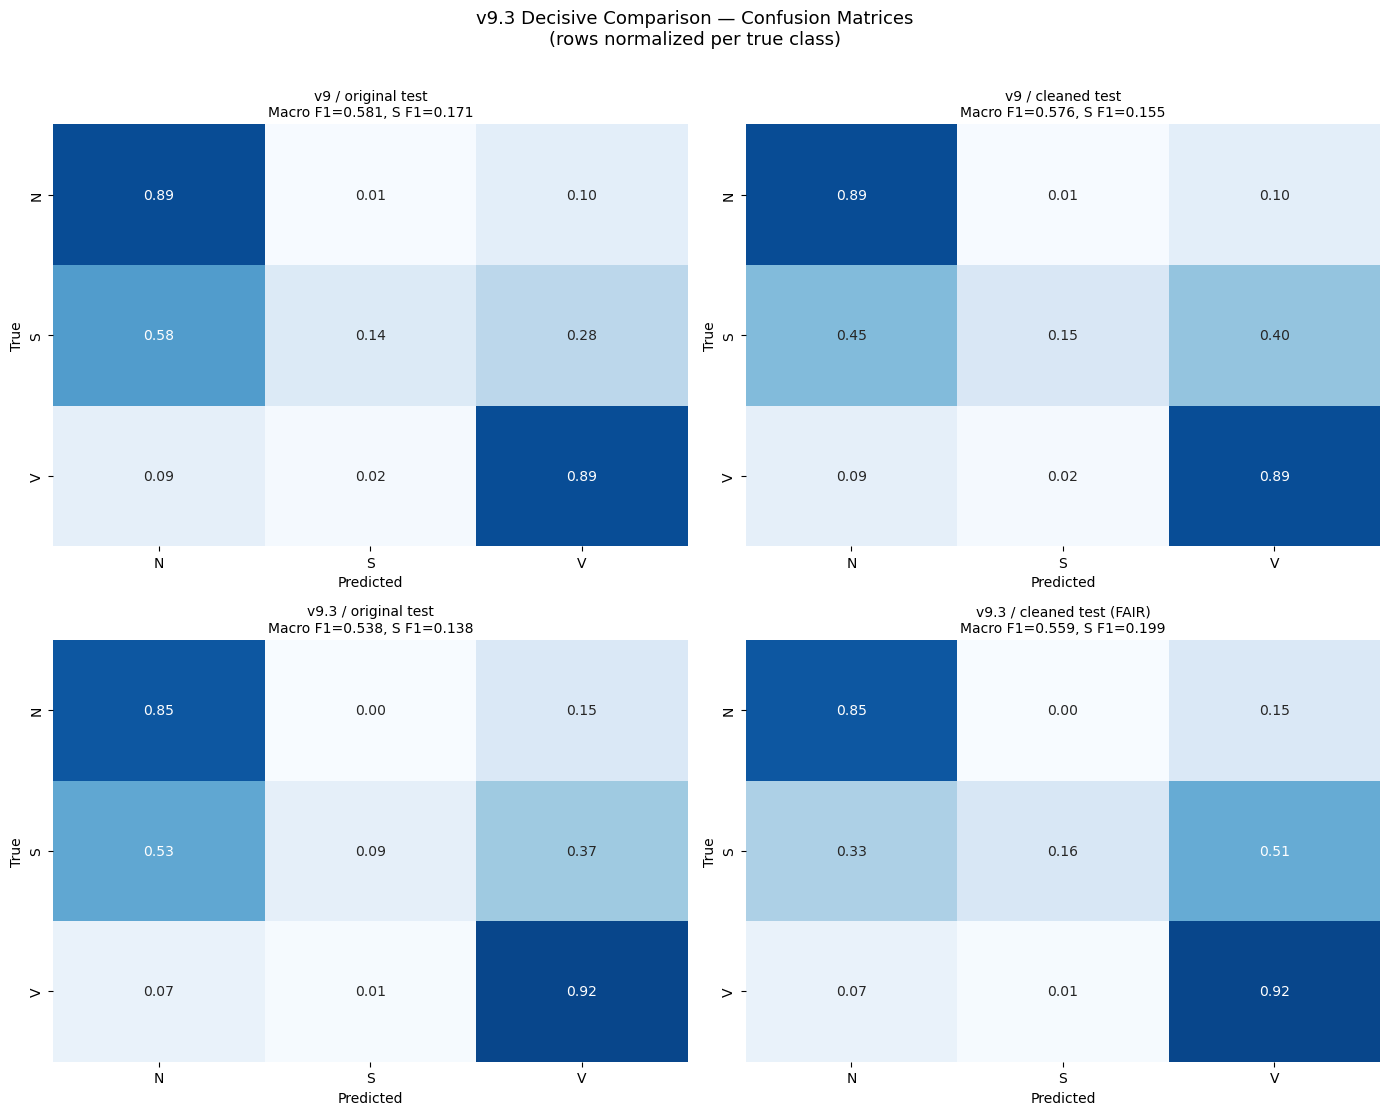

Saved: outputs_v93/confusion_matrices_comparison.png


In [12]:
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
configs = [
    ('v9 / original test', results['v9_orig_test']),
    ('v9 / cleaned test', results['v9_clean_test']),
    ('v9.3 / original test', results['v93_orig_test']),
    ('v9.3 / cleaned test (FAIR)', results['v93_clean_test']),
]
for ax, (title, r) in zip(axes.flatten(), configs):
    cm = np.array(r['cm'])
    # Normalize per row (per true class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
                cbar=False, vmin=0, vmax=1)
    ax.set_title(f'{title}\nMacro F1={r["macro_f1"]:.3f}, S F1={r["S_f1"]:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.suptitle('v9.3 Decisive Comparison — Confusion Matrices\n(rows normalized per true class)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_V93}/confusion_matrices_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUTS_V93}/confusion_matrices_comparison.png")


## Step 11 — Per-patient S breakdown on v9.3

Did v9.3 recover S beats from the patients that v9 completely missed (mitbih_207, 209, 234)?

In [13]:
# Per-patient S recall/precision for v9.3 on cleaned test
gate_probs_test = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_pass = gate_probs_test > V93_GATE_THR
y_pred_v93 = np.full(len(y_test), n_idx, dtype=int)
if gate_pass.any():
    v_p, s_p = sv_model.predict([X_test[gate_pass], X_rr_test_norm[gate_pass]],
                                 batch_size=256, verbose=0)
    v_p = v_p.flatten(); s_p = s_p.flatten()
    routed = np.full(len(v_p), n_idx, dtype=int)
    v_fire = v_p > V93_V_THR; routed[v_fire] = v_idx
    s_fire = (~v_fire) & (s_p > V93_S_THR); routed[s_fire] = s_idx
    y_pred_v93[gate_pass] = routed

print(f"{'='*90}")
print(f"PER-PATIENT S BREAKDOWN — v9.3 on cleaned test")
print(f"{'='*90}")
print(f"{'Patient':<14} {'n_S_clean':>10} {'n_S_orig':>9} {'S_recall':>9} {'S_prec':>8} {'S_pred':>7}")
print(f"{'-'*60}")

# Also compute v9 baseline per-patient for comparison
gate_probs_test_v9 = gate_v9.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_pass_v9 = gate_probs_test_v9 > V9_GATE_THR
y_pred_v9 = np.full(len(y_test_orig), n_idx, dtype=int)
if gate_pass_v9.any():
    v_p, s_p = sv_v9.predict([X_test[gate_pass_v9], X_rr_test_norm[gate_pass_v9]],
                              batch_size=256, verbose=0)
    v_p = v_p.flatten(); s_p = s_p.flatten()
    routed = np.full(len(v_p), n_idx, dtype=int)
    v_fire = v_p > V9_V_THR; routed[v_fire] = v_idx
    s_fire = (~v_fire) & (s_p > V9_S_THR); routed[s_fire] = s_idx
    y_pred_v9[gate_pass_v9] = routed

print(f"\n{'Patient':<14} {'clean_S':>8} {'v9_recall':>10} {'v93_recall':>11} {'Δ':>8}")
print(f"{'-'*55}")
total_v9_tp = 0; total_v93_tp = 0; total_clean_s = 0
for rec_tag in sorted(set(recs_test)):
    pat_mask = recs_test == rec_tag
    pat_clean_s = int(np.sum((y_test == s_idx) & pat_mask))
    pat_orig_s = int(np.sum((y_test_orig == s_idx) & pat_mask))
    if pat_clean_s == 0 and pat_orig_s == 0: continue
    # v9 recall (on original labels)
    v9_tp = int(np.sum((y_test_orig == s_idx) & pat_mask & (y_pred_v9 == s_idx)))
    v9_rec = v9_tp / max(pat_orig_s, 1)
    # v9.3 recall (on cleaned labels)
    v93_tp = int(np.sum((y_test == s_idx) & pat_mask & (y_pred_v93 == s_idx)))
    v93_rec = v93_tp / max(pat_clean_s, 1)
    d = v93_rec - v9_rec
    marker = '★' if d > 0.1 else ('✓' if d > 0 else ' ')
    print(f"{marker} {rec_tag:<12} {pat_clean_s:>8} {v9_rec:>10.3f} {v93_rec:>11.3f} {d:>+8.3f}")
    total_v9_tp += v9_tp; total_v93_tp += v93_tp; total_clean_s += pat_clean_s

print(f"{'-'*55}")
print(f"  TOTAL         {total_clean_s:>8} {total_v9_tp/max(int(np.sum(y_test_orig==s_idx)),1):>10.3f} "
      f"{total_v93_tp/max(total_clean_s,1):>11.3f}")

# Specifically check the zero-recovery patients
print(f"\n{'='*90}")
print(f"ZERO-RECOVERY PATIENTS (v9 recovered 0 S beats — did v9.3 do better?)")
print(f"{'='*90}")
zero_rec = ['mitbih_207', 'mitbih_118', 'mitbih_223', 'mitbih_203', 'mitbih_228', 'mitbih_231']
for pat in zero_rec:
    pat_mask = recs_test == pat
    pat_clean_s = int(np.sum((y_test == s_idx) & pat_mask))
    pat_orig_s = int(np.sum((y_test_orig == s_idx) & pat_mask))
    v93_tp = int(np.sum((y_test == s_idx) & pat_mask & (y_pred_v93 == s_idx)))
    v9_tp = int(np.sum((y_test_orig == s_idx) & pat_mask & (y_pred_v9 == s_idx)))
    print(f"  {pat}: orig S={pat_orig_s}, cleaned S={pat_clean_s}, "
          f"v9 recovered={v9_tp}, v9.3 recovered={v93_tp}")


PER-PATIENT S BREAKDOWN — v9.3 on cleaned test
Patient         n_S_clean  n_S_orig  S_recall   S_prec  S_pred
------------------------------------------------------------

Patient         clean_S  v9_recall  v93_recall        Δ
-------------------------------------------------------
★ mitbih_101          3      0.333       0.667   +0.333
★ mitbih_108          4      0.000       0.500   +0.500
  mitbih_112          2      0.500       0.500   +0.000
  mitbih_114          8      0.000       0.000   +0.000
  mitbih_116          1      0.000       0.000   +0.000
  mitbih_118         93      0.198       0.000   -0.198
★ mitbih_201        127      0.141       0.252   +0.111
✓ mitbih_202         54      0.218       0.315   +0.097
  mitbih_203          1      0.000       0.000   +0.000
  mitbih_205          1      0.333       0.000   -0.333
  mitbih_207         11      0.000       0.000   +0.000
  mitbih_208          0      0.000       0.000   +0.000
✓ mitbih_209        149      0.144       0.2

## What this means

### If v9.3's S F1 jumped (label noise was the blocker)

The S problem was never a model problem. It was a data problem. The last 9 versions of architecture changes — dual heads, cascade routing, joint sweeps, RR branch experiments, gate capacity increases, window resize — were all chasing noise. The model couldn't learn to classify non-premature beats as "premature" because they aren't.

**v9.3 becomes the new baseline.** Next steps:
- Tune hyperparameters on the cleaned data (the v9 joint sweep was calibrated to noisy labels)
- Re-investigate the window size question (v9.1 C1 showed gate S-recall improved at 200 samples — does that hold on cleaned data?)
- The RR branch question (v9.1 A) should be re-tested on cleaned data — the val finding may have been noise, but it might also have been real and masked by label noise

### If v9.3's S F1 didn't jump (genuine model failure)

Even genuinely-premature S beats are too hard for this architecture. The label noise was real but not the bottleneck. Next steps:
- The architecture is fundamentally limited — consider a different approach (transformer, attention, or feature engineering)
- The 130-sample window may genuinely clip P-waves needed for S identification
- The 2-lead input may be insufficient — some S subtypes are only distinguishable on specific leads

### Either way, this experiment was necessary

Every previous version was confounded by label noise. v9.3 is the first version where the train and test S labels are clean. Whatever the result, it's the first trustworthy S F1 number in the project's history.
